In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from typing import List
random.seed(42)
np.random.seed(42)


In [2]:
NUMBER_OF_ARMS = 10
NO_OF_TASKS = 2000
TIME_RANGE = 1000

In [3]:
true_reward_distr = np.random.standard_normal((NUMBER_OF_ARMS,))
estimate_of_rewards = list(np.random.standard_normal((NUMBER_OF_ARMS,)))
best_arm_idx = np.argmax(true_reward_distr)
print(true_reward_distr)
print(f"Best arm: {best_arm_idx}")

[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004]
Best arm: 6


In [4]:
def epsilon_greedy(true_reward_distr: List[float], estimate_of_rewards: List[float], epsilon: float) -> List[float]:
    rewards_obtained = []
    
    number_of_times_arms_played = [0 for _ in range(NUMBER_OF_ARMS)]    
    number_of_times_best_arm_chosen = 0

    for t in range(1,TIME_RANGE+1):

        if np.random.rand() <= epsilon:
            arm_chosen = np.random.randint(0, NUMBER_OF_ARMS)        
        else:
            arm_chosen = np.argmax(estimate_of_rewards)

        number_of_times_arms_played[arm_chosen] += 1 

        #Random sampling + noise 
        reward_obtained = np.random.normal(true_reward_distr[arm_chosen],1)

        #Recalculating estimate of arm reward
        estimate_of_rewards[arm_chosen] = (estimate_of_rewards[arm_chosen] + reward_obtained)/(number_of_times_arms_played[arm_chosen])
        rewards_obtained.append(reward_obtained)

        # Number of times best arm played
        if arm_chosen == best_arm_idx:
            number_of_times_best_arm_chosen += 1

    return rewards_obtained, number_of_times_best_arm_chosen


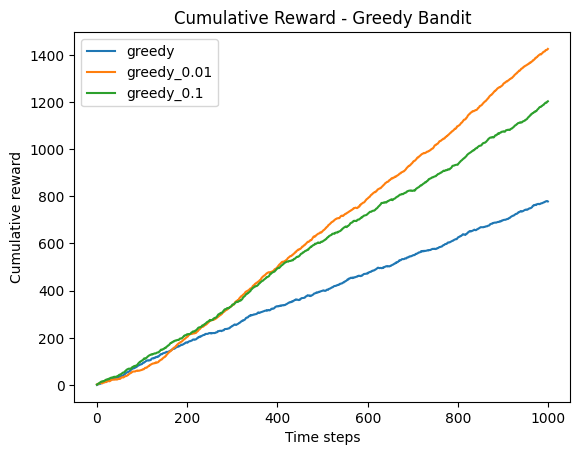

In [5]:
greedy_rewards_obtained,_ = epsilon_greedy(true_reward_distr,estimate_of_rewards,0)
epsilon_0_01_greedy_rewards_obtained,_ = epsilon_greedy(true_reward_distr,estimate_of_rewards,0.01)
epsilon_0_1_greedy_rewards_obtained,_ = epsilon_greedy(true_reward_distr,estimate_of_rewards,0.1)


plt.plot(np.cumsum(greedy_rewards_obtained),label='greedy')
plt.plot(np.cumsum(epsilon_0_01_greedy_rewards_obtained),label='greedy_0.01')
plt.plot(np.cumsum(epsilon_0_1_greedy_rewards_obtained),label='greedy_0.1')
plt.title('Cumulative Reward - Greedy Bandit')
plt.xlabel('Time steps')
plt.ylabel('Cumulative reward')
plt.legend()
plt.show()